# Livrable 1 
Groupe : 
* Isrâ BOUDEMAGH
* Théophile NOEL
* Bruno RIECKENBERG
* Corentin ROMANO

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
import pathlib
import shutil

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

print(tf.__version__)
print("Compilé avec CUDA :", tf.test.is_built_with_cuda())
print("GPU détectés :", tf.config.list_physical_devices('GPU'))


I0000 00:00:1791182239.747231     870 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791182240.084978     870 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791182241.739572     870 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0
Compilé avec CUDA : True
GPU détectés : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1791182244.017185     870 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
dataset_path = pathlib.Path("./dataset")
print([p.name for p in dataset_path.iterdir()])

['Others', 'Painting', 'Photo']


In [4]:
from PIL import Image
import shutil

def nettoyer_dataset(root, dossier_rejets):
    root, dossier_rejets = pathlib.Path(root), pathlib.Path(dossier_rejets)
    reparees, rejetees = [], []
    for p in sorted(root.rglob("*")):
        if not p.is_file():
            continue
        try:
            tf.io.decode_image(tf.io.read_file(str(p)), channels=3, expand_animations=False)
        except tf.errors.InvalidArgumentError:
            try:
                with Image.open(p) as im:
                    im = im.convert("RGB")
                im.save(p, "JPEG", quality=95)   # ré-encodage en vrai JPEG
                reparees.append(p)
            except Exception:
                cible = dossier_rejets / p.relative_to(root)
                cible.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(p), str(cible))  # image illisible : on la sort du dataset
                rejetees.append(p)
    print(f"{len(reparees)} réparée(s), {len(rejetees)} rejetée(s)")
    return reparees, rejetees

nettoyer_dataset(dataset_path, "../Livrable1,1_rejets")


W0000 00:00:1791182249.784706     870 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1791182249.975299     870 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1791182489.330252     870 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


0 réparée(s), 0 rejetée(s)


([], [])

In [5]:
image_h = 200
image_w = 200
batch_s = 128

In [6]:
# Le train_set
train_set = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_path,
  validation_split=  0.2,
  subset =  'training',
  seed=42,
  image_size = (image_h, image_w),
  batch_size = batch_s
)
# Le test_set
test_set = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_path,
  validation_split= 0.2,
  subset = 'validation',
  seed= 42,
  image_size = (image_h, image_w),
  batch_size = batch_s
)

Found 41399 files belonging to 3 classes.
Using 33120 files for training.
Found 41399 files belonging to 3 classes.
Using 8279 files for validation.


In [7]:
class_names = train_set.class_names
print(class_names)

['Others', 'Painting', 'Photo']


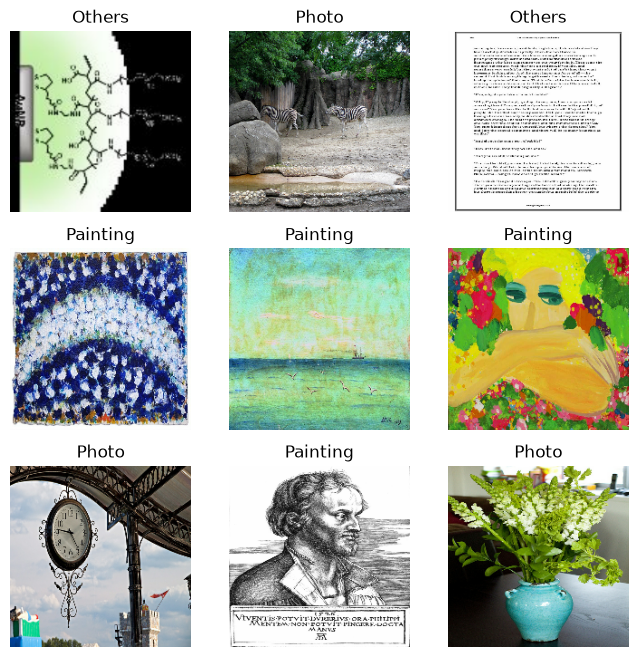

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_set.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [9]:
print(type(train_set))
images, labels =  next(iter(train_set))
print(images.shape)
print(labels.shape)

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(128, 200, 200, 3)
(128,)


In [11]:
# AUTOTUNE = tf.data.experimental.AUTOTUNE

# train_set = train_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
# test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(image_h, image_w, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

/home/theophile/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
epochs=150
learning_rate = 1e-3
# Le modèle
complete_model =  Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(image_h, image_w, 3)),
    layers.Conv2D(16, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), padding='same', activation='leaky_relu'),
    layers.Flatten(),
    layers.Dense(256, activation='leaky_relu'),
    layers.Dropout(0.2),  # Couche de dropout pour régularisation
    layers.Dense(3, activation='softmax')  # 3 classes de sortie
])
# Compilation du modèle
complete_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])
#Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=epochs//10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=epochs//100,
    min_lr=0.00001,
    verbose=1
)
# Résumé du modèle
complete_model.summary()
# Entrainement du modèle
# complete_history = complete_model.fit(train_set,
#                                       epochs=epochs,
#                                       validation_data=(test_set),
#                                       callbacks=[reduce_lr, early_stopping])
# acc = complete_history.history['accuracy']
# val_acc = complete_history.history['val_accuracy']

# loss = complete_history.history['loss']
# val_loss = complete_history.history['val_loss']

# epochs_range = range(len(acc))

# plt.figure(figsize=(16, 8))
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, acc, label='Training Accuracy')
# plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# plt.legend(loc='lower right')
# plt.title('Training and Validation Accuracy')

# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, loss, label='Training Loss')
# plt.plot(epochs_range, val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.title('Training and Validation Loss')
# plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,578,467 (78.50 MB)

 Trainable params: 20,578,467 (78.50 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def afficher_matrice_confusion(model, dataset, class_names, normaliser=False):
    y_true, y_pred = [], []
    # On prédit batch par batch dans la MÊME boucle que les labels (voir remarque plus bas)
    for images, labels in dataset:
        logits = model.predict_on_batch(images)
        y_true.append(labels.numpy())
        y_pred.append(np.argmax(logits, axis=1))
    y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()
    if normaliser:
        cm = cm / cm.sum(axis=1, keepdims=True)   # proportions par classe réelle

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)), labels=class_names)
    ax.set_yticks(range(len(class_names)), labels=class_names)
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe réelle")
    ax.set_title(f"Matrice de confusion — accuracy {np.mean(y_true == y_pred):.1%}")

    # Valeur écrite dans chaque case (texte blanc sur les cases foncées)
    seuil = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texte = f"{cm[i, j]:.1%}" if normaliser else f"{cm[i, j]:d}"
            ax.text(j, i, texte, ha="center", va="center",
                    color="white" if cm[i, j] > seuil else "black")

    plt.tight_layout()
    plt.show()
    return cm

# cm = afficher_matrice_confusion(complete_model, test_set, class_names)
# cm_norm = afficher_matrice_confusion(complete_model, test_set, class_names, normaliser=True)


In [13]:
model_path = pathlib.Path("./models")
model_path.mkdir(exist_ok=True, parents=True)

# complete_model.save(model_path / "lucky_model1,1.keras")
# print(f"Modèle sauvegardé dans : {model_path.resolve()}")

In [22]:
model_file_path = model_path / "lucky_model1.1.keras"
complete_model = keras.models.load_model(model_file_path)

complete_model.summary()
complete_model.evaluate(test_set)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,735,403 (235.50 MB)

 Trainable params: 20,578,467 (78.50 MB)

 Non-trainable params: 0 (0.00 B)

...

/home/theophile/envs/tf-gpu/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:1402: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


12/65 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.9284 - loss: 0.2157

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.9199 - loss: 0.2232


[0.22318437695503235, 0.9199178814888]

Jauconde.jpg                 → Painting  | Others   0.0%  Painting 100.0%  Photo   0.0%
Terre.jpg                    → Others    | Others  58.3%  Painting   9.0%  Photo  32.7%
etrange.jpg                  → Photo     | Others   0.0%  Painting   4.4%  Photo  95.6%
homme devant fenetre.jpg     → Photo     | Others   0.3%  Painting   7.2%  Photo  92.4%
nuit sous les étoiles.jpg    → Painting  | Others   0.2%  Painting  99.7%  Photo   0.0%
peinture wiki.jpg            → Painting  | Others   0.1%  Painting  82.5%  Photo  17.4%
photo1.jpg                   → Photo     | Others   0.0%  Painting  34.6%  Photo  65.4%
photo2.jpg                   → Photo     | Others   1.2%  Painting  27.2%  Photo  71.6%
photo3.jpg                   → Photo     | Others   3.9%  Painting   8.1%  Photo  88.0%
photo4.jpg                   → Others    | Others  77.9%  Painting  21.9%  Photo   0.2%
tropius.jpg                  → Others    | Others  67.9%  Painting  27.6%  Photo   4.5%
voie_lactée.jpg              → P

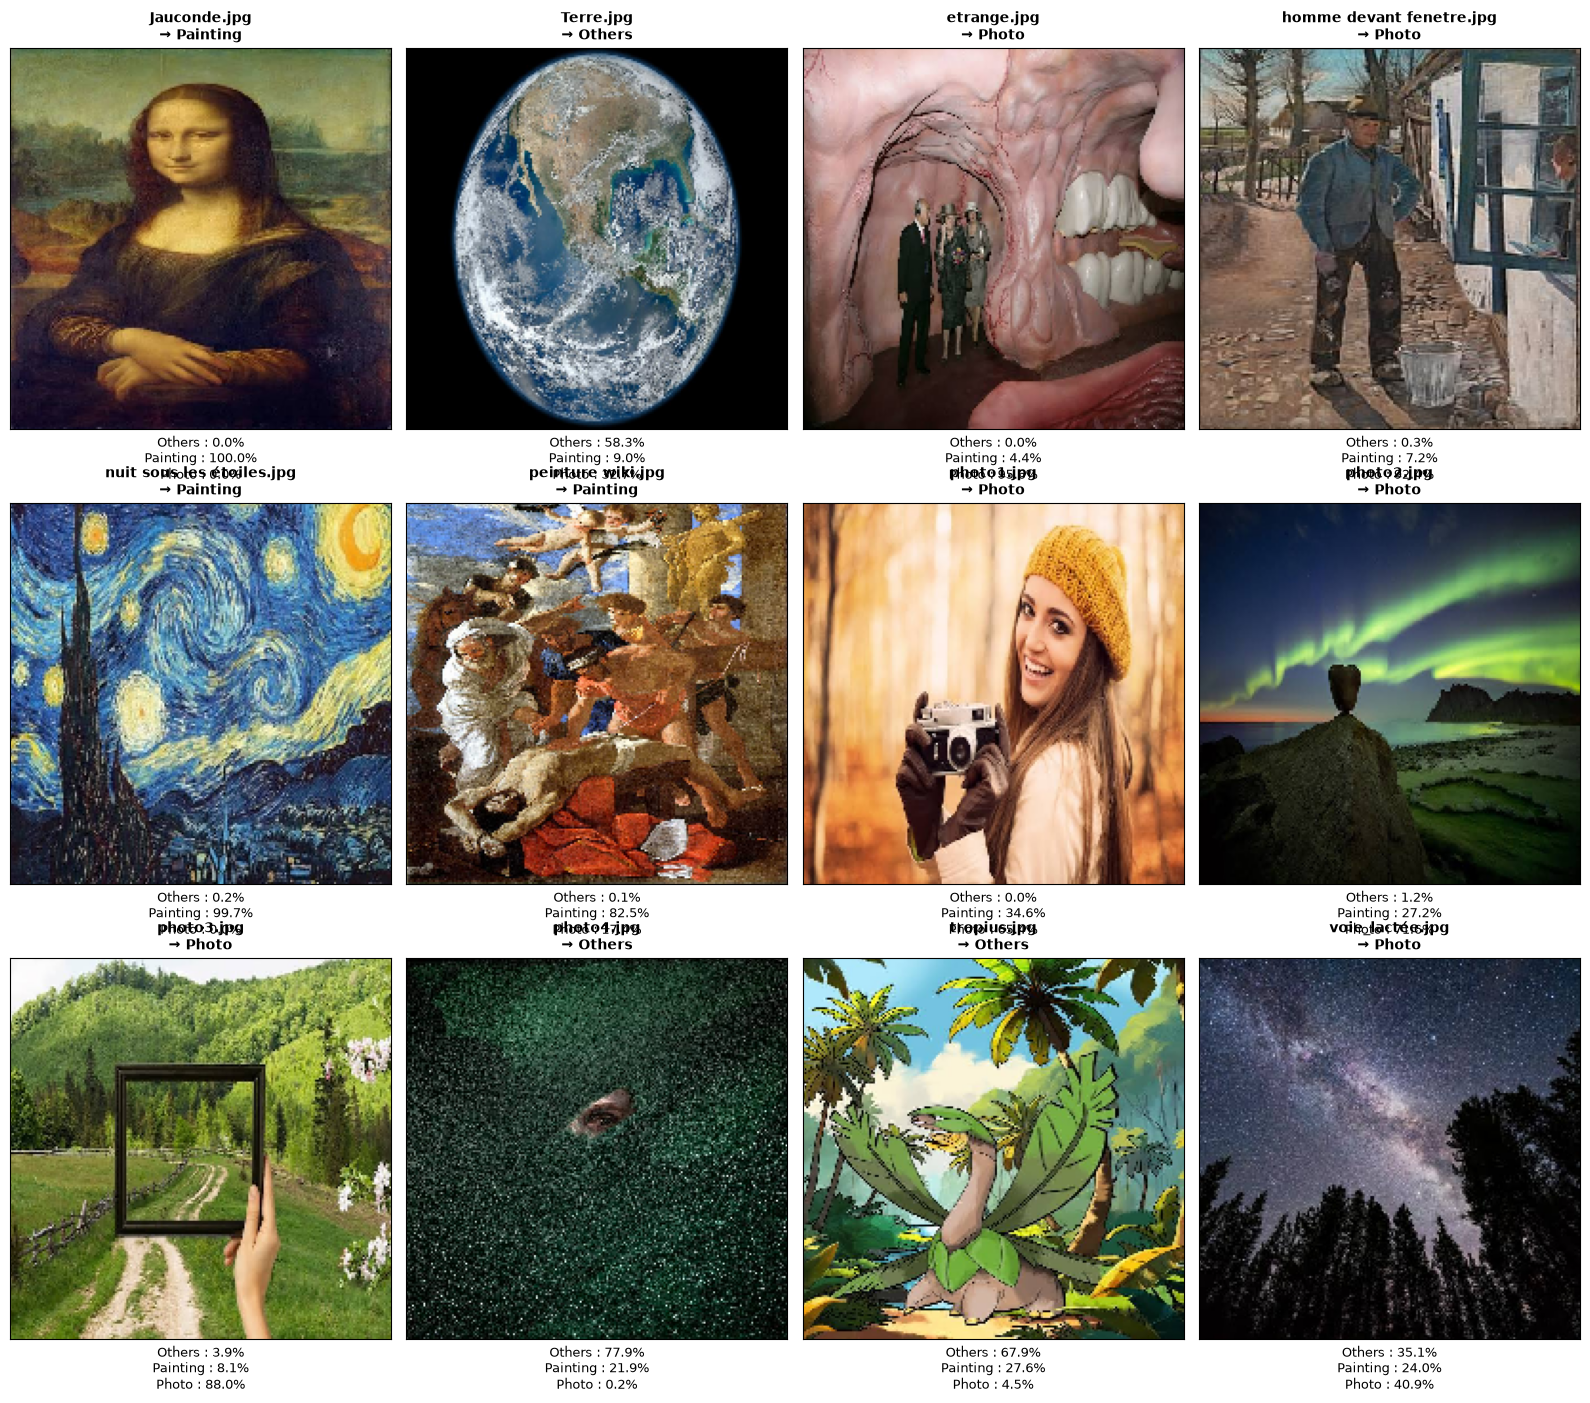

In [15]:
test_photos_dir = pathlib.Path("../Test_photos")
extensions_images = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
nb_colonnes = 4

# Le modèle doit avoir autant de sorties que de classes (3 : Others, Painting, Photo)
nb_sorties = complete_model.output_shape[-1]
if nb_sorties != len(class_names):
    raise ValueError(
        f"Le modèle a {nb_sorties} sorties mais il y a {len(class_names)} classes {class_names}. "
        "Vérifie que complete_model est bien le modèle entraîné sur ce dataset."
    )

# Si la dernière couche a déjà un softmax, ses sorties sont des probabilités : on ne le réapplique pas
sortie_softmax = getattr(complete_model.layers[-1].activation, "__name__", "") == "softmax"

if not test_photos_dir.is_dir():
    raise FileNotFoundError(f"Dossier introuvable : {test_photos_dir.resolve()}")

image_paths = sorted(
    p for p in test_photos_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions_images
)

if not image_paths:
    print(f"Aucune image trouvée dans {test_photos_dir.resolve()}")
else:
    images = [keras.utils.load_img(p, target_size=(image_h, image_w), color_mode="rgb") for p in image_paths]
    batch = np.stack([keras.utils.img_to_array(img) for img in images])

    # Une seule prédiction pour toutes les images (plus rapide et moins de mémoire qu'une par image)
    sorties = complete_model.predict(batch, verbose=0)
    probabilities = sorties if sortie_softmax else tf.nn.softmax(sorties, axis=1).numpy()

    nb_lignes = int(np.ceil(len(images) / nb_colonnes))
    fig = plt.figure(figsize=(4 * nb_colonnes, 4.6 * nb_lignes))
    for i, (image_path, image, probas) in enumerate(zip(image_paths, images, probabilities)):
        predicted_index = int(np.argmax(probas))
        detail = "\n".join(f"{name} : {p:.1%}" for name, p in zip(class_names, probas))

        ax = fig.add_subplot(nb_lignes, nb_colonnes, i + 1)
        ax.imshow(image)
        ax.set_title(f"{image_path.name}\n→ {class_names[predicted_index]}", fontsize=10, fontweight="bold")
        ax.set_xlabel(detail, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

        print(f"{image_path.name:<28} → {class_names[predicted_index]:<9} | "
              + "  ".join(f"{name} {p:6.1%}" for name, p in zip(class_names, probas)))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Création d'un modèle de discrimination entre les photos et les paintures.

In [16]:
classes_p2p = ["Painting", "Photo"]

image_h, image_w = 400,400
batch_s = 16

train_set_p2p = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(image_h, image_w),
    batch_size=batch_s,
    class_names=classes_p2p
)

test_set_p2p = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(image_h, image_w),
    batch_size=batch_s,
    class_names=classes_p2p
)

Found 19993 files belonging to 2 classes.
Using 15995 files for training.
Found 19993 files belonging to 2 classes.
Using 3998 files for validation.


In [19]:
data_augmentation_p2p = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(image_h, image_w, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 400, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 400, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 400, 400, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 200, 200, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 200, 200, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    40,960,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,057,826 (156.62 MB)

 Trainable params: 41,057,826 (156.62 MB)

 Non-trainable params: 0 (0.00 B)

...

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.9594 - loss: 0.1111 - val_accuracy: 0.9300 - val_loss: 0.2158 - learning_rate: 1.0000e-05
Epoch 40/150
 364/1000 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9530 - loss: 0.1215

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9580 - loss: 0.1131

W0000 00:00:1791041143.476966   16493 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 80ms/step - accuracy: 0.9580 - loss: 0.1131 - val_accuracy: 0.9340 - val_loss: 0.2089 - learning_rate: 1.0000e-05
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.


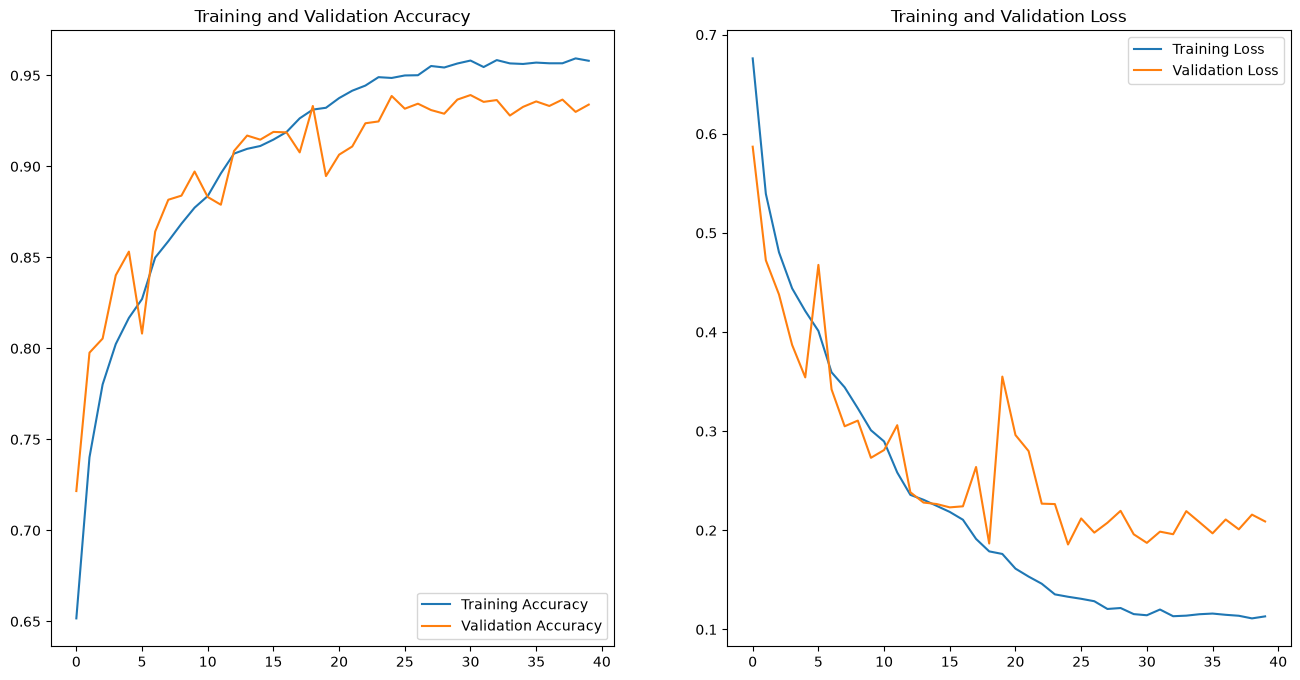

In [20]:
epochs=150
learning_rate = 1e-3
# Le modèle
complete_model_p2p =  Sequential([
    data_augmentation_p2p,
    layers.Rescaling(1./255, input_shape=(image_h, image_w, 3)),
    layers.Conv2D(16, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), padding='same', activation='leaky_relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), padding='same', activation='leaky_relu'),
    layers.Flatten(),
    layers.Dense(128, activation='leaky_relu'),
    layers.Dropout(0.2),  # Couche de dropout pour régularisation
    layers.Dense(2, activation='softmax')  # 2 classes de sortie
])
# Compilation du modèle
complete_model_p2p.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                       loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                       metrics=['accuracy'])
#Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=epochs//10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=epochs//100,
    min_lr=0.00001,
    verbose=1
)
# Résumé du modèle
complete_model_p2p.summary()
# Entrainement du modèle
complete_history_p2p = complete_model_p2p.fit(train_set_p2p,
                                          epochs=epochs,
                                          validation_data=(test_set_p2p),
                                          callbacks=[reduce_lr, early_stopping])
acc = complete_history_p2p.history['accuracy']
val_acc = complete_history_p2p.history['val_accuracy']

loss = complete_history_p2p.history['loss']
val_loss = complete_history_p2p.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

W0000 00:00:1791183000.593611    6402 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


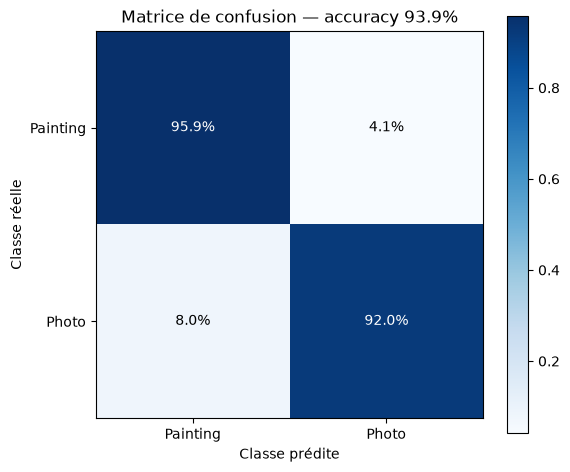

In [21]:
cm_norm = afficher_matrice_confusion(complete_model_p2p, test_set_p2p, classes_p2p, normaliser=True)

In [17]:
# model_path = pathlib.Path("./models")
# model_path.mkdir(exist_ok=True, parents=True)

complete_model_p2p.save(model_path / "lucky_model1,1_p2p.keras")
print(f"Modèle sauvegardé dans : {model_path.resolve()}")

NameError: name 'complete_model_p2p' is not defined

In [20]:
model_file_path = model_path / "lucky_model1,1_p2p.keras"
complete_model_p2p = keras.models.load_model(model_file_path)

Jauconde.jpg                 classique : Painting  → finale : Painting 
Terre.jpg                    classique : Others    → finale : Others     (P2P non exécuté)
etrange.jpg                  classique : Photo     → finale : Photo    
homme devant fenetre.jpg     classique : Photo     → finale : Painting 
nuit sous les étoiles.jpg    classique : Painting  → finale : Painting 
peinture wiki.jpg            classique : Painting  → finale : Painting 
photo1.jpg                   classique : Photo     → finale : Photo    
photo2.jpg                   classique : Photo     → finale : Photo    
photo3.jpg                   classique : Photo     → finale : Photo    
photo4.jpg                   classique : Painting  → finale : Painting 
tropius.jpg                  classique : Others    → finale : Others     (P2P non exécuté)
voie_lactée.jpg              classique : Photo     → finale : Painting 


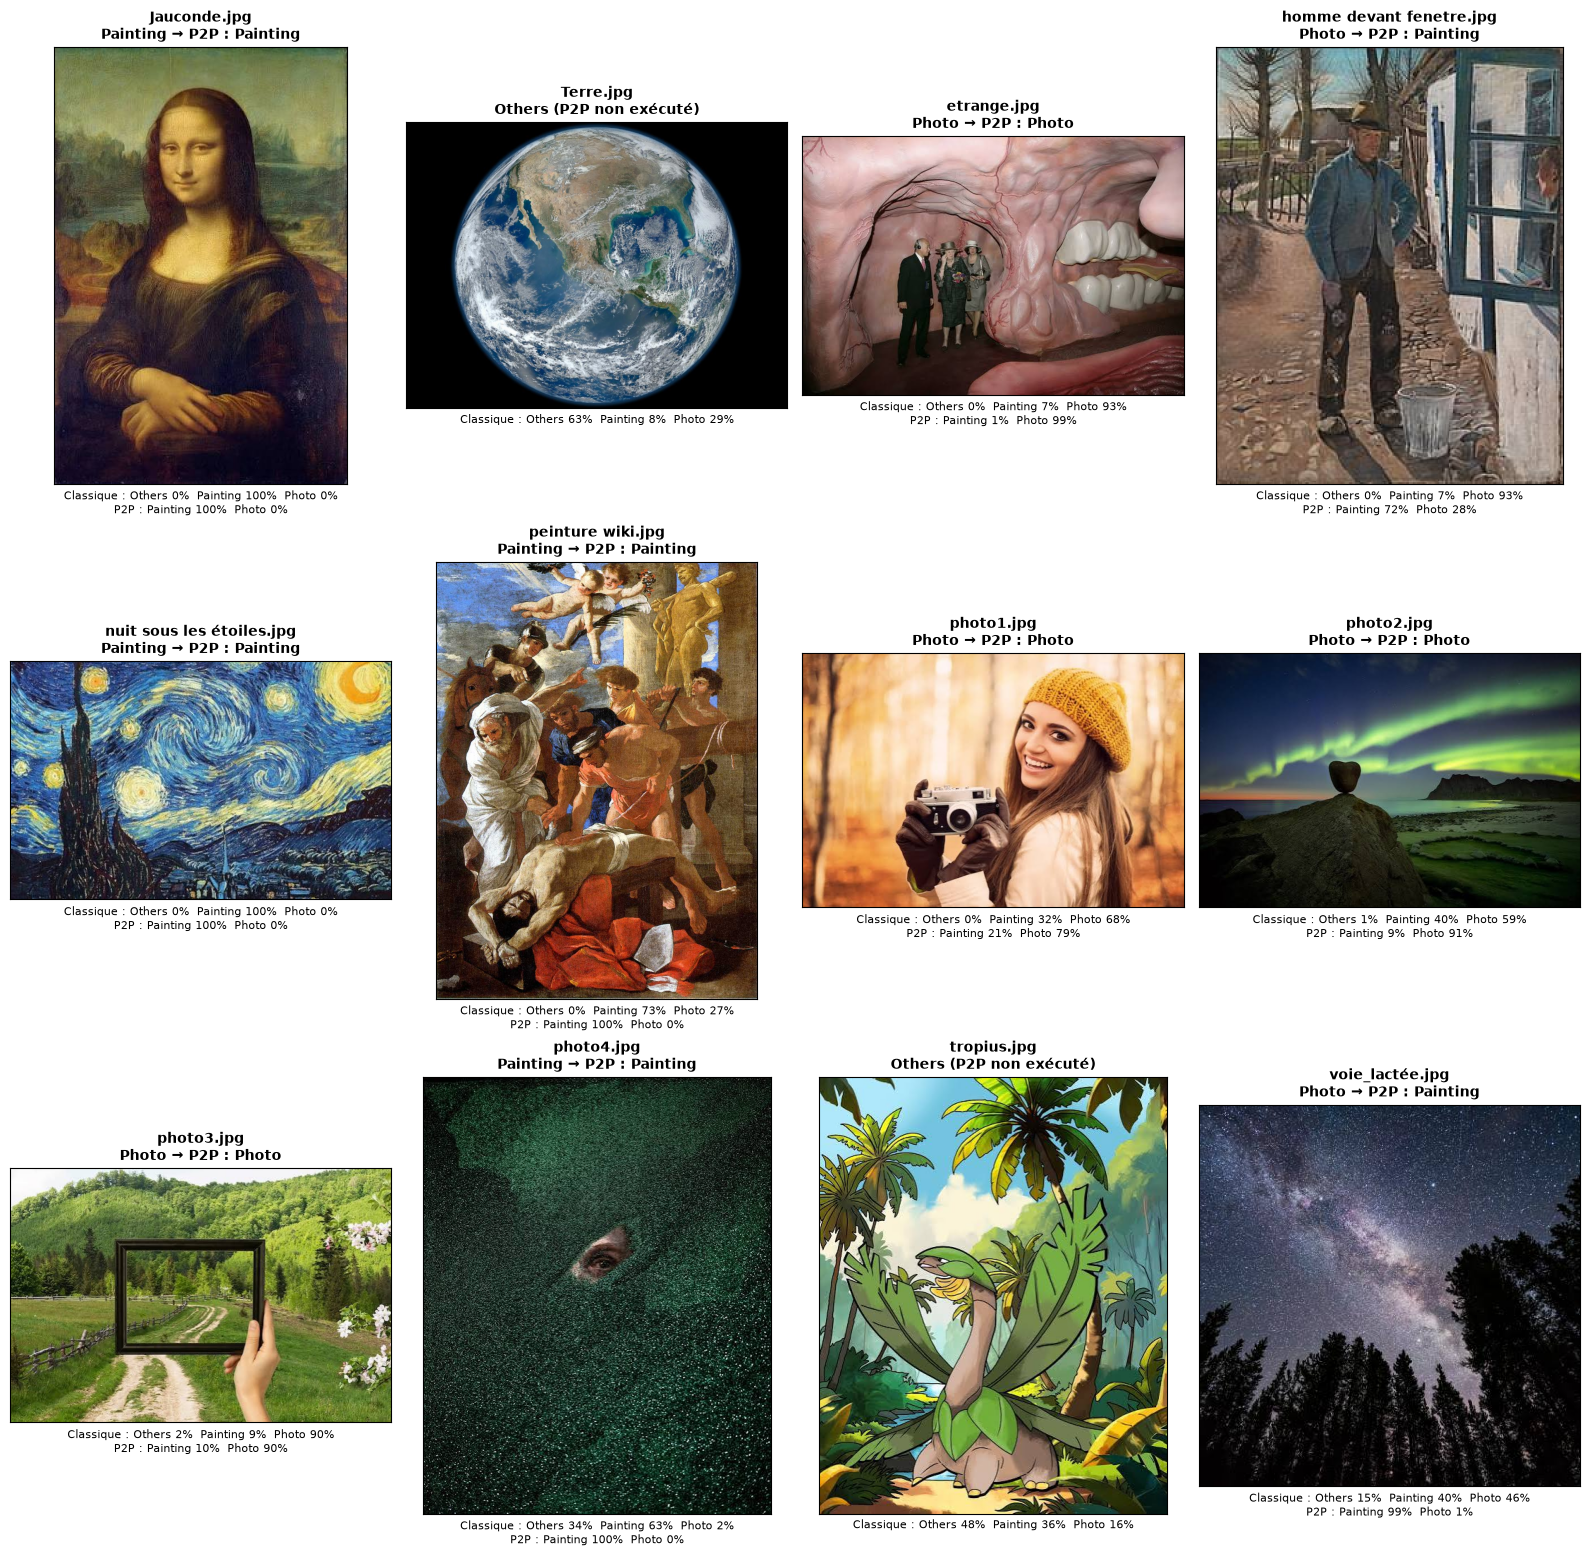

In [23]:
test_photos_dir = pathlib.Path("../Test_photos")
extensions_images = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
nb_colonnes = 4
classes_p2p = ["Painting", "Photo"]

# Chaque modèle doit avoir autant de sorties que de classes (3 pour le classique, 2 pour le P2P)
for modele, classes in [(complete_model, class_names), (complete_model_p2p, classes_p2p)]:
    if modele.output_shape[-1] != len(classes):
        raise ValueError(
            f"Le modèle {modele.name} a {modele.output_shape[-1]} sorties mais il y a {len(classes)} classes {classes}. "
            "Vérifie que c'est bien le modèle entraîné sur ces classes."
        )

def predire_probas(modele, images_pil):
    # Chaque modèle a sa propre taille d'entrée (200x200 pour le classique, 400x400 pour le P2P) :
    # on la lit dans le modèle plutôt que dans image_h / image_w, qui ont été réécrits pour le P2P.
    # tf.image.resize redimensionne comme image_dataset_from_directory pendant l'entraînement
    h, w = modele.input_shape[1:3]
    batch = np.stack([tf.image.resize(keras.utils.img_to_array(img), (h, w)).numpy() for img in images_pil])
    # Une seule prédiction pour toutes les images (plus rapide et moins de mémoire qu'une par image)
    sorties = modele.predict(batch, verbose=0)
    # Si la dernière couche a déjà un softmax, ses sorties sont des probabilités : on ne le réapplique pas
    sortie_softmax = getattr(modele.layers[-1].activation, "__name__", "") == "softmax"
    return sorties if sortie_softmax else tf.nn.softmax(sorties, axis=1).numpy()

if not test_photos_dir.is_dir():
    raise FileNotFoundError(f"Dossier introuvable : {test_photos_dir.resolve()}")

image_paths = sorted(
    p for p in test_photos_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions_images
)

if not image_paths:
    print(f"Aucune image trouvée dans {test_photos_dir.resolve()}")
else:
    # Images chargées en taille d'origine : chaque modèle les redimensionne à sa propre taille
    images = [keras.utils.load_img(p, color_mode="rgb") for p in image_paths]

    # Étape 1 : le modèle classique trie toutes les images (Others / Painting / Photo)
    probas_classique = predire_probas(complete_model, images)
    predictions_classique = np.argmax(probas_classique, axis=1)

    # Étape 2 : seules les images prédites Painting ou Photo repassent dans le modèle P2P
    indices_p2p = [i for i, idx in enumerate(predictions_classique) if class_names[idx] in classes_p2p]
    probas_p2p = {}
    if indices_p2p:
        sorties_p2p = predire_probas(complete_model_p2p, [images[i] for i in indices_p2p])
        probas_p2p = dict(zip(indices_p2p, sorties_p2p))

    nb_lignes = int(np.ceil(len(images) / nb_colonnes))
    fig = plt.figure(figsize=(4 * nb_colonnes, 5.2 * nb_lignes))
    for i, (image_path, image) in enumerate(zip(image_paths, images)):
        classe_classique = class_names[predictions_classique[i]]
        detail = "Classique : " + "  ".join(f"{name} {p:.0%}" for name, p in zip(class_names, probas_classique[i]))

        if i in probas_p2p:
            classe_finale = classes_p2p[int(np.argmax(probas_p2p[i]))]
            detail += "\nP2P : " + "  ".join(f"{name} {p:.0%}" for name, p in zip(classes_p2p, probas_p2p[i]))
            titre = f"{classe_classique} → P2P : {classe_finale}"
        else:
            classe_finale = classe_classique
            titre = f"{classe_classique} (P2P non exécuté)"

        ax = fig.add_subplot(nb_lignes, nb_colonnes, i + 1)
        ax.imshow(image)
        ax.set_title(f"{image_path.name}\n{titre}", fontsize=10, fontweight="bold")
        ax.set_xlabel(detail, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

        print(f"{image_path.name:<28} classique : {classe_classique:<9} → finale : {classe_finale:<9}"
              + ("" if i in probas_p2p else "  (P2P non exécuté)"))

    plt.tight_layout()
    plt.show()
    plt.close(fig)